In [1]:
# Import libraries
import pickle
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy.sparse as sp 
import matplotlib.pyplot as plt
import anndata
from anndata import AnnData

# For plotting
import seaborn as sns

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For umap
import umap

# SCVI
import scvi
import cellxgene_census
import cellxgene_census.experimental

# For ML training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from scipy.sparse import issparse, vstack

/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/home/aoku/.local/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
import warnings

# Suppress specific types of warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### Load data

In [3]:
# Load path (path contains seurat object with our annotations)
czi_path = "/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/62_harmony_102224_Seuratv34_newannot_counts.h5ad"

# Read the h5ad file
adata = sc.read_h5ad(czi_path)

print(adata)

AnnData object with n_obs × n_vars = 171459 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

In [4]:
# Get counts data (scVi requires count info)
adata.layers["counts"] = adata.raw.X.copy()
adata.layers["logcounts"] = adata.X.copy()

In [5]:
# Add HECA annotations to adata (annotation from published HECA dataset)
heca_annot = pd.read_csv("/nfs/home/rfu/projects/CZI_endom/CZI_HECAtype.csv.gz")

# Check if cell index matches
print(pd.Series(adata.obs_names == heca_annot.cell).value_counts())

# Add to anndata
adata.obs["heca_celltype"] = heca_annot["celltype"].values
adata.obs["heca_lineage"] = heca_annot["lineage"].values


True    171459
Name: count, dtype: int64


In [7]:
print(adata)

AnnData object with n_obs × n_vars = 171459 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

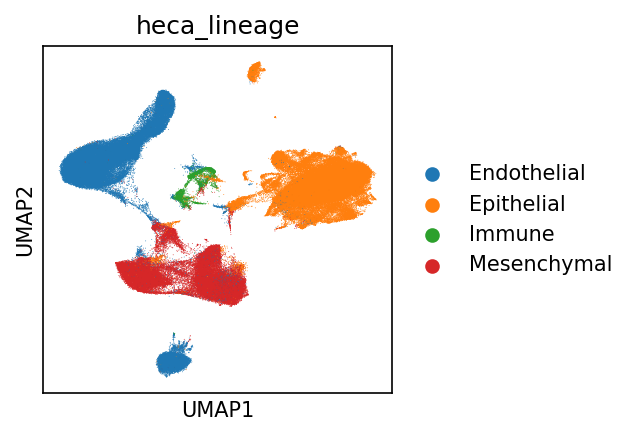

In [8]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata, color='heca_lineage')

In [9]:
# Prep data for scVI

#Get ensembl IDs - map gene symbol to ensembl ID
gene_ids = pd.read_csv("/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/gene_names_gene_ids_czi_endo.csv", index_col= False)

gene_id_dict = pd.DataFrame({
    'gene_symbol': gene_ids["gene_name"],
    'ensembl_id': gene_ids["gene_id"]})

gene_id_dict = gene_id_dict.set_index('gene_symbol')['ensembl_id'].to_dict()

ensembl_ids = [gene_id_dict.get(gene, 'NA') for gene in adata.var_names]

# Add ensembl IDs to anndata object
adata.var["gene_names"] = adata.var_names

adata.var["ensembl_ids"] = ensembl_ids
adata.var_names = ensembl_ids

# Remove duplicated IDs
adata = adata[:, ~adata.var["ensembl_ids"].duplicated()].copy()

# Check for duplicated IDs
adata.var["ensembl_ids"].duplicated().any()

del adata.varm["HARMONY"]
del adata.varm["PCs"]

In [10]:
#### Split data into training and testing sets
# Get unique sample IDs
unique_ids = adata.obs['id'].unique()

# Split the sample IDs
train_ids, test_ids = train_test_split(unique_ids, test_size=0.15, random_state=42)

# Create boolean masks
train_mask = adata.obs['id'].isin(train_ids)
test_mask = adata.obs['id'].isin(test_ids)

# Subset the AnnData object
adata_train = adata[train_mask].copy()
adata_test = adata[test_mask].copy()

In [11]:
#adata_test.obs["heca_lineage"].value_counts()
len(adata_test.obs["id"].unique())

10

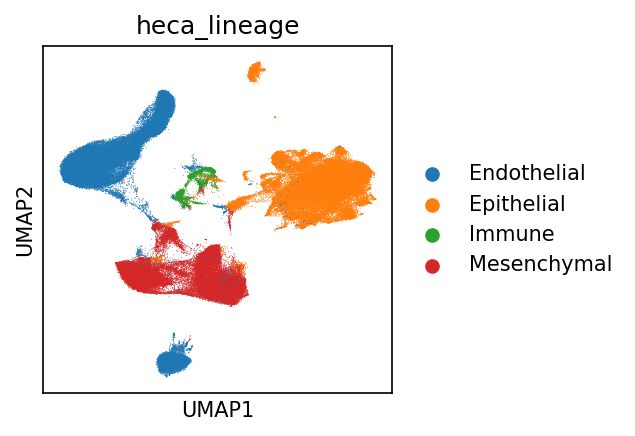

In [12]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_train, color='heca_lineage')

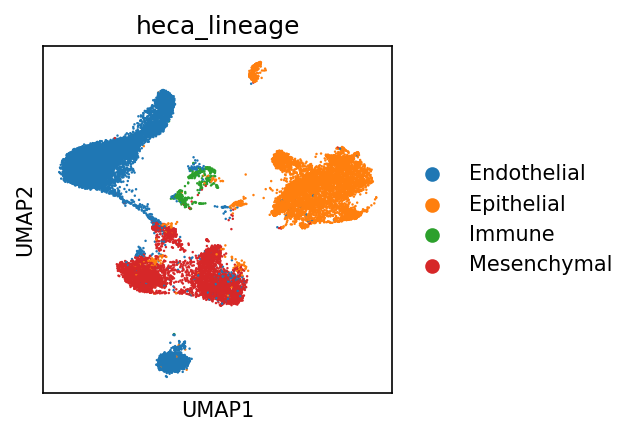

In [13]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_test, color='heca_lineage')

In [14]:
# Function to get true pseudobulk from a single data
def true_pseudo_bulk_by_sample(adata: AnnData, sample_key="id", cell_type_key="cell_type"):
    # Ensure raw counts are used (convert sparse to dense if needed)
    print("convert counts data to array")
    X = adata.X.toarray()

    print("conversion to array done!")

    # Create a DataFrame from raw counts
    print("convert to dataframe")
    expr_df = pd.DataFrame(X, index=adata.obs.index, columns=adata.var_names)

    print("add sample name column") 
    expr_df[sample_key] = adata.obs[sample_key].values

    print("add cell type key")
    #expr_df[cell_type_key] = adata.obs[cell_type_key].values

    # Sum counts per gene for each sample (pseudobulk)
    print("group by sample and sum counts")
    pseudo_bulk_df = expr_df.groupby(sample_key).sum()

    # Calculate cell type proportions per sample
    print("grpup by sample and cell to get cell proportion info")
    ct_counts = adata.obs.groupby([sample_key, cell_type_key]).size().unstack(fill_value=0)

    print("divide by total cell count to get proportion")
    ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)

    print("done!")

    return pseudo_bulk_df, ct_props


In [15]:
def create_pseudobulk_with_random_celltype_proportions_counts(
    adata: AnnData,
    n_samples: int = 2000,
    cells_per_sample: int = 2000,
    cell_type_col: str = "cell_type",
    seed: int = 42
):
    """
    Create pseudobulk samples from raw counts in an AnnData object with random cell type proportions.
    Uses sparse operations to avoid memory issues.
    """
    np.random.seed(seed)
    
    # Get cell types and sparse matrix
    cell_types = adata.obs[cell_type_col].unique()
    X = adata.X  # keep sparse if already sparse

    # Precompute cell index pools
    celltype_to_indices = {
        ct: np.where(adata.obs[cell_type_col] == ct)[0]
        for ct in cell_types
    }

    pseudobulk_profiles = []
    pseudobulk_props = []

    alpha_val = 10

    for i in range(n_samples):
        proportions = np.random.dirichlet(np.ones(len(cell_types)) * alpha_val)
        cells_per_type = (proportions * cells_per_sample).astype(int)

        sampled_indices = []
        for ct, n_cells in zip(cell_types, cells_per_type):
            pool = celltype_to_indices[ct]
            if len(pool) == 0 or n_cells == 0:
                continue
            sampled = np.random.choice(pool, size=n_cells, replace=True)
            sampled_indices.extend(sampled)

        # Stack and sum sparse matrix slices
        sampled_X = X[sampled_indices]
        summed = sampled_X.sum(axis=0)  # returns 1 × n_genes matrix

        if issparse(summed):
            summed = summed.A1  # convert to flat array
        else:
            summed = np.asarray(summed).flatten()

        pseudobulk_profiles.append(summed)

        # Proportions
        selected_cell_types = adata.obs.iloc[sampled_indices][cell_type_col]
        props = selected_cell_types.value_counts(normalize=True).reindex(cell_types, fill_value=0)
        pseudobulk_props.append(props)

    pseudobulk_df = pd.DataFrame(pseudobulk_profiles, columns=adata.var_names)
    pseudobulk_df.index = [f"sample_{i+1}" for i in range(n_samples)]

    celltype_props_df = pd.DataFrame(pseudobulk_props)
    celltype_props_df.index = pseudobulk_df.index
    celltype_props_df.columns.name = "cell_type"

    return pseudobulk_df, celltype_props_df


In [16]:
# WRITE A BETTER FUNCTION TO GENERATE PSEUDOBULK

In [44]:
import anndata
import pandas as pd
import numpy as np
from sklearn.utils import check_random_state
import warnings

def create_pseudobulk_and_proportions(
    adata: anndata.AnnData, # anndata object
    sample_id_col: str,      # column name corresponding to the sample ID
    cell_type_col: str,      # column name corresponding to the cell type
    n_pseudobulks_per_sample: int = 30,
    min_prop: float = 0.1,
    max_prop: float = 0.9,
    n_cells_per_pseudobulk: int = 300, # Fixed number of cells per pseudobulk
    max_attempts_per_pseudobulk: int = 100,
    random_state: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Creates pseudobulk expression profiles and corresponding cell type proportions from an AnnData object.

    Pseudobulks are created by summing up expression of cells from the same sample_id.
    Multiple pseudobulk samples are created from a single sample_id.
    Cell type proportions within each pseudobulk are constrained to be within a specified range
    (min_prop to max_prop) for all cell types present in that pseudobulk.
    A fixed number of cells is used for each pseudobulk.

    Args:
        adata: The input AnnData object.
        sample_id_col: The column name in adata.obs where sample IDs are stored.
        cell_type_col: The column name in adata.obs where cell types are stored.
        n_pseudobulks_per_sample: The number of pseudobulk samples to create for each unique sample ID.
        min_prop: The minimum proportion for any cell type present in a pseudobulk.
                  (e.g., 0.1 means 10%)
        max_prop: The maximum proportion for any cell type present in a pseudobulk.
                  (e.g., 0.9 means 90%)
        n_cells_per_pseudobulk: The fixed number of cells to include in each pseudobulk.
        max_attempts_per_pseudobulk: Maximum attempts to create a pseudobulk that satisfies
                                     the proportion constraints. If exceeded, a warning is printed,
                                     and the pseudobulk is created with the last sampled cells
                                     (which may not meet the proportion criteria).
        random_state: Seed for the random number generator to ensure reproducibility.

    Returns:
        A tuple containing:
        - pseudobulk_df: A pandas DataFrame where rows are pseudobulk samples and columns are genes,
                         containing summed expression values.
        - proportions_df: A pandas DataFrame where rows are pseudobulk samples and columns are cell types,
                          containing the proportions of each cell type in the pseudobulk.

    Raises:
        ValueError: If sample_id_col or cell_type_col are not found in adata.obs.
        ValueError: If min_prop is not less than max_prop.
        ValueError: If min_prop or max_prop are outside the [0, 1] range.
        ValueError: If n_cells_per_pseudobulk is not greater than 0.
    """

    # --- Input Validation ---
    if sample_id_col not in adata.obs.columns:
        raise ValueError(f"Sample ID column '{sample_id_col}' not found in adata.obs.")
    if cell_type_col not in adata.obs.columns:
        raise ValueError(f"Cell type column '{cell_type_col}' not found in adata.obs.")
    if not (0 <= min_prop < max_prop <= 1):
        raise ValueError("min_prop must be less than max_prop, and both must be between 0 and 1.")
    if not (n_cells_per_pseudobulk > 0):
        raise ValueError("n_cells_per_pseudobulk must be greater than 0.")

    # --- Setup ---
    rng = check_random_state(random_state)
    unique_sample_ids = adata.obs[sample_id_col].unique()
    all_cell_types = adata.obs[cell_type_col].unique()

    pseudobulk_data_list = []
    proportions_data_list = []
    pseudobulk_sample_names = []

    # --- Process each unique sample ID ---
    for sample_id in unique_sample_ids:
        # Subset adata for the current sample
        adata_sample = adata[adata.obs[sample_id_col] == sample_id]

        # Get available cell types within this sample
        sample_cell_types = adata_sample.obs[cell_type_col].unique()
        
        # Determine if diversity constraint can be met for this sample
        # If a sample has fewer than 2 distinct cell types, it's impossible to meet
        # the diversity constraint (e.g., 10-90% range for multiple types).
        # In this case, the pseudobulk will consist of 100% of the single cell type.
        can_meet_diversity = len(sample_cell_types) >= 2

        # --- Create multiple pseudobulks for the current sample ---
        for i in range(n_pseudobulks_per_sample):
            valid_pseudobulk_found = False
            attempt_count = 0
            
            # Variables to store the results of the last attempt, in case constraints aren't met
            last_selected_original_indices = None
            last_current_pb_proportions_raw = None

            # Determine the number of cells for this pseudobulk
            # Use n_cells_per_pseudobulk, but cap it at the total available cells in the sample
            num_cells_for_pb = min(n_cells_per_pseudobulk, adata_sample.shape[0])

            if num_cells_for_pb == 0: # No cells available in this sample
                warnings.warn(f"Sample '{sample_id}' has no cells. Skipping pseudobulk creation for this sample (PB {i+1}).")
                continue # Move to the next pseudobulk for this sample_id

            # Loop to try and create a pseudobulk that meets proportion criteria
            while not valid_pseudobulk_found and attempt_count < max_attempts_per_pseudobulk:
                attempt_count += 1

                # Randomly sample cell indices from the current sample
                selected_original_indices = rng.choice(
                    adata_sample.obs.index,
                    size=num_cells_for_pb,
                    replace=False # Ensure unique cells are selected for each pseudobulk
                ).tolist()
                
                # Calculate actual cell type proportions for the selected cells
                selected_cell_types_series = adata.obs.loc[selected_original_indices, cell_type_col]
                current_pb_counts = selected_cell_types_series.value_counts()
                current_pb_proportions_raw = current_pb_counts / current_pb_counts.sum()

                # Check if proportions meet the diversity criteria
                proportions_met = True
                if can_meet_diversity: # Only apply diversity check if multiple cell types are possible
                    for ct, prop in current_pb_proportions_raw.items():
                        if not (min_prop <= prop <= max_prop):
                            proportions_met = False
                            break
                
                if proportions_met:
                    valid_pseudobulk_found = True
                
                # Always store the results of the current attempt
                last_selected_original_indices = selected_original_indices
                last_current_pb_proportions_raw = current_pb_proportions_raw

            # After the while loop, create the pseudobulk using the last sampled cells
            # (either the one that met criteria, or the one from the last attempt)
            if not valid_pseudobulk_found:
                warnings.warn(f"Could not create a pseudobulk for sample '{sample_id}' (PB {i+1}) "
                              f"satisfying proportion constraints after {max_attempts_per_pseudobulk} attempts. "
                              "A pseudobulk will be created with the last sampled cells, which may not "
                              "meet the diversity criteria. Consider relaxing min/max_prop, "
                              "increasing max_attempts_per_pseudobulk, or checking cell type distribution.")

            # Store the pseudobulk expression
            # Ensure X is handled correctly for sparse vs. dense matrices
            pb_expression_matrix = adata[last_selected_original_indices, :].X
            if isinstance(pb_expression_matrix, (np.ndarray, pd.DataFrame)):
                # If dense, sum directly
                pb_expression_sum = pb_expression_matrix.sum(axis=0)
            else: # Assume sparse matrix (e.g., scipy.sparse.csr_matrix)
                # Convert to dense 1D array after summing for consistent output
                pb_expression_sum = pb_expression_matrix.sum(axis=0).A1 

            pseudobulk_data_list.append(pb_expression_sum)

            # Store the cell type proportions (fill 0 for absent types to ensure consistent columns)
            proportions_dict = {ct: 0.0 for ct in all_cell_types}
            for ct, prop in last_current_pb_proportions_raw.items():
                proportions_dict[ct] = prop
            proportions_data_list.append(proportions_dict)

            # Generate a unique name for the pseudobulk sample
            pseudobulk_sample_names.append(f"{sample_id}_PB{i+1}")
                
    # --- Create final DataFrames ---
    if not pseudobulk_data_list:
        warnings.warn("No pseudobulk samples were successfully created. Returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame()

    pseudobulk_df = pd.DataFrame(
        pseudobulk_data_list,
        index=pseudobulk_sample_names,
        columns=adata.var_names
    )

    proportions_df = pd.DataFrame(
        proportions_data_list,
        index=pseudobulk_sample_names
    )
    # Ensure all_cell_types are columns, filling missing with 0 for consistency
    proportions_df = proportions_df.reindex(columns=all_cell_types, fill_value=0.0)

    return pseudobulk_df, proportions_df

In [46]:
# This function makes randomly pseudobulk samples without using sample ID (sample_id agnostic)
#pseudobulk_czi, pseudobulk_czi_cell_prop = create_pseudobulk_with_random_celltype_proportions_counts(adata= adata_train, cell_type_col="heca_lineage")

In [47]:
pseudobulk_czi, pseudobulk_czi_cell_prop =  create_pseudobulk_and_proportions(adata=adata_train, cell_type_col="heca_lineage", sample_id_col="id")

In [48]:
print(pseudobulk_czi.shape)
print(pseudobulk_czi.iloc[0:6, 0:6])
print(pseudobulk_czi.shape)

(1650, 36592)
               ENSG00000243485  ENSG00000237613  ENSG00000186092  \
B2-CZI08N_PB1              0.0              0.0              0.0   
B2-CZI08N_PB2              0.0              0.0              0.0   
B2-CZI08N_PB3              0.0              0.0              0.0   
B2-CZI08N_PB4              0.0              0.0              0.0   
B2-CZI08N_PB5              0.0              0.0              0.0   
B2-CZI08N_PB6              0.0              0.0              0.0   

               ENSG00000238009  ENSG00000239945  ENSG00000239906  
B2-CZI08N_PB1              1.0              0.0              0.0  
B2-CZI08N_PB2              1.0              0.0              0.0  
B2-CZI08N_PB3              3.0              0.0              0.0  
B2-CZI08N_PB4              2.0              1.0              0.0  
B2-CZI08N_PB5              0.0              0.0              0.0  
B2-CZI08N_PB6              0.0              0.0              0.0  
(1650, 36592)


In [49]:
pseudobulk_czi_cell_prop[pseudobulk_czi_cell_prop.index.str.split('_').str[0] == 'B2-CZI08N'].Endothelial

B2-CZI08N_PB1     0.530000
B2-CZI08N_PB2     0.496667
B2-CZI08N_PB3     0.500000
B2-CZI08N_PB4     0.620000
B2-CZI08N_PB5     0.550000
B2-CZI08N_PB6     0.520000
B2-CZI08N_PB7     0.530000
B2-CZI08N_PB8     0.536667
B2-CZI08N_PB9     0.530000
B2-CZI08N_PB10    0.550000
B2-CZI08N_PB11    0.560000
B2-CZI08N_PB12    0.530000
B2-CZI08N_PB13    0.543333
B2-CZI08N_PB14    0.540000
B2-CZI08N_PB15    0.563333
B2-CZI08N_PB16    0.586667
B2-CZI08N_PB17    0.550000
B2-CZI08N_PB18    0.506667
B2-CZI08N_PB19    0.533333
B2-CZI08N_PB20    0.503333
B2-CZI08N_PB21    0.540000
B2-CZI08N_PB22    0.536667
B2-CZI08N_PB23    0.513333
B2-CZI08N_PB24    0.563333
B2-CZI08N_PB25    0.506667
B2-CZI08N_PB26    0.553333
B2-CZI08N_PB27    0.540000
B2-CZI08N_PB28    0.553333
B2-CZI08N_PB29    0.513333
B2-CZI08N_PB30    0.496667
Name: Endothelial, dtype: float64

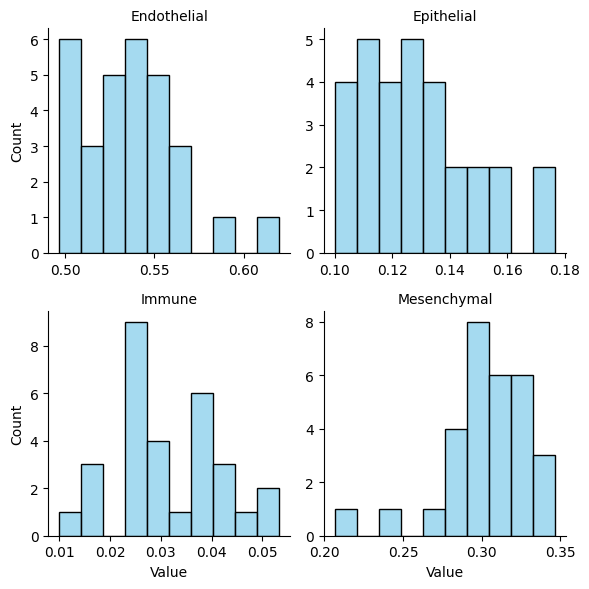

In [50]:
# Explore cell type proportions
# Reshape the data to long format
df_long = pseudobulk_czi_cell_prop[pseudobulk_czi_cell_prop.index.str.split('_').str[0] == 'B2-CZI08N'].melt(var_name='Variable', value_name='Value')

# Create facet plot
g = sns.FacetGrid(df_long, col='Variable', col_wrap=2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=10, color='skyblue')

# Adjust layout
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()

In [51]:
# Create pseudobulk
#pseudobulk_czi, pseudobulk_czi_cell_prop = true_pseudo_bulk_by_sample(adata= adata, sample_key="id", cell_type_key="newtype")

In [52]:
# Inspect results
pseudobulk_czi.iloc[0:50, 0:4].head(5)

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009
B2-CZI08N_PB1,0.0,0.0,0.0,1.0
B2-CZI08N_PB2,0.0,0.0,0.0,1.0
B2-CZI08N_PB3,0.0,0.0,0.0,3.0
B2-CZI08N_PB4,0.0,0.0,0.0,2.0
B2-CZI08N_PB5,0.0,0.0,0.0,0.0


In [53]:
# Inspect results
pseudobulk_czi_cell_prop.iloc[0:20, 0:4].head(10)

,Endothelial,Immune,Mesenchymal,Epithelial
B2-CZI08N_PB1,0.530000,0.023333,0.270000,0.176667
B2-CZI08N_PB2,0.496667,0.053333,0.306667,0.143333
B2-CZI08N_PB3,0.500000,0.030000,0.330000,0.140000
B2-CZI08N_PB4,0.620000,0.036667,0.206667,0.136667
B2-CZI08N_PB5,0.550000,0.043333,0.306667,0.100000
B2-CZI08N_PB6,0.520000,0.023333,0.320000,0.136667
B2-CZI08N_PB7,0.530000,0.040000,0.316667,0.113333
B2-CZI08N_PB8,0.536667,0.046667,0.300000,0.116667
B2-CZI08N_PB9,0.530000,0.023333,0.346667,0.100000
B2-CZI08N_PB10,0.550000,0.036667,0.303333,0.110000


### Get scVI embeddings for bulk data

In [54]:
# convert bulk to anndata
X = pseudobulk_czi  # Now rows = samples, columns = genes

# Create AnnData object
adata_bulk = anndata.AnnData(X)

# Set sample names and gene names
adata_bulk.obs_names = X.index     
adata_bulk.var_names = X.columns 

# Add batch information
adata_bulk.obs["batch"] = "czi pseudobulk"
adata_bulk.obs["id"] = X.index 

In [55]:
# # Split data into training and testing sets
# # Get unique sample IDs
# unique_ids = adata_bulk.obs['id'].unique()

# # Split the sample IDs
# train_ids, test_ids = train_test_split(unique_ids, test_size=0.15, random_state=42)

# # Create boolean masks
# train_mask = adata_bulk.obs['id'].isin(train_ids)
# test_mask = adata_bulk.obs['id'].isin(test_ids)

# # Subset the AnnData object
# adata_bulk_train = adata_bulk[train_mask].copy()
# adata_bulk_test = adata_bulk[test_mask].copy()

In [56]:
# Define scVI path
scvi_path = "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01"

# Extract scVI embeddings with single forward pass
scvi.model.SCVI.prepare_query_anndata(adata_bulk, 
                                      scvi_path)

vae_q = scvi.model.SCVI.load_query_data(
    adata_bulk,
    scvi_path,
)

# # This allows for a simple forward pass
vae_q.is_trained = True
latent_czi_pseudobulk = vae_q.get_latent_representation()

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 63.5375% reference vars in query data.                                                              
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [57]:
# Convert to dataframe
latent_czi_pseudobulk = pd.DataFrame(latent_czi_pseudobulk)
latent_czi_pseudobulk.index = adata_bulk.obs["id"]

In [58]:
# Define X and y 
X = latent_czi_pseudobulk
y = pseudobulk_czi_cell_prop.loc[latent_czi_pseudobulk.index, :]

In [59]:
# Identify missing values
missing_indices = y[y.isna().any(axis=1)].index

# Drop those from both X and y
X = X.drop(index=missing_indices)
y = y.drop(index=missing_indices)

In [60]:
missing_indices

Index([], dtype='object', name='id')

In [61]:
# Train regressor model
# Split data into training and test splits
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [62]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1320, 50)
(1320, 4)
(330, 50)
(330, 4)


In [63]:
y_train.isna().sum()

Endothelial    0
Immune         0
Mesenchymal    0
Epithelial     0
dtype: int64

In [64]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [65]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(X_test)

# Convert to DataFrame
predicted_proportions = pd.DataFrame(y_pred, columns=y_test.columns, index=X_test.index)

In [66]:
def plot_true_vs_predicted(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


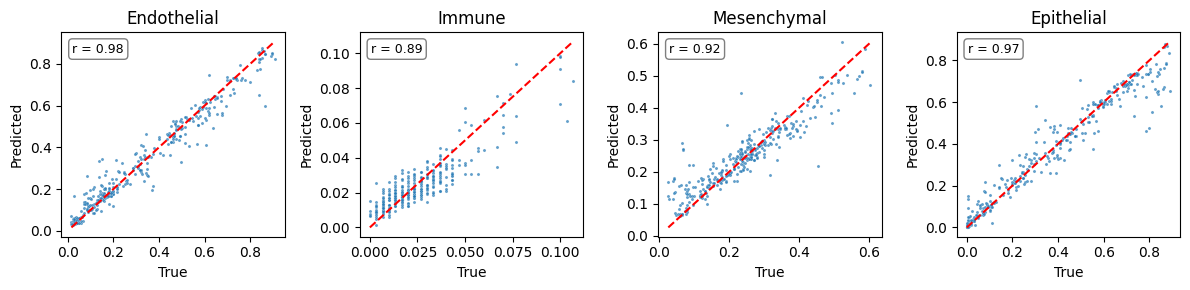

In [67]:
# Plot correlations (pearson)
plot_true_vs_predicted(y_test,predicted_proportions)

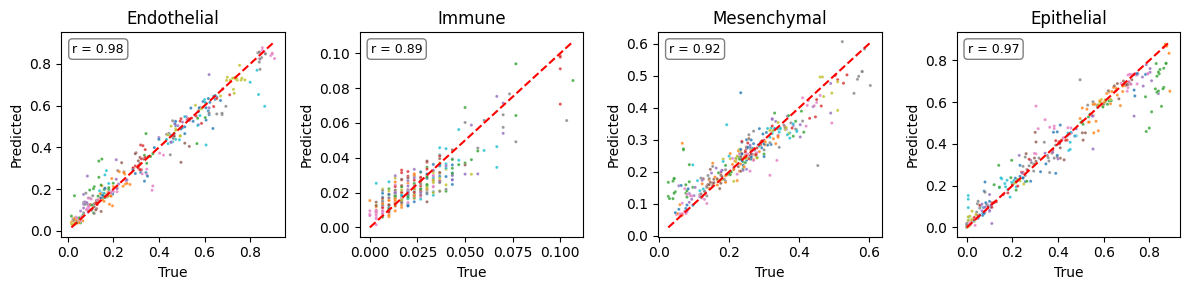

In [68]:
def plot_true_vs_predicted_with_color(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5):

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import pearsonr

    # Sample group for coloring
    color = y_test_df.index.str.split('_').str[0]

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot with hue
        sns.scatterplot(x=x, y=y, hue=color, palette="tab10", alpha=0.8, ax=ax, s=dot_size, legend=False)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
plot_true_vs_predicted_with_color(y_test,predicted_proportions)

In [69]:
adata_train.obs.groupby(["id", "heca_lineage"]).size().unstack(fill_value=0)
y_test.index.str.split('_').str[0].unique()

Index(['B8-CZI025N', 'B3-CZI05N', 'B12-CZI042N', 'B2-CZI08N', 'B14-CZI248N',
       'B9-CZI021N', 'B5-CZI22N', 'B15-CZI363N', 'B4P1-CZI01N', 'B13-CZI232N',
       'B19-CZI237N', 'B7-CZI027N', 'B18-CZI336N', 'B7-CZI030N', 'B16-CZI182N',
       'B13-CZI016N', 'B9-CZI029N', 'B5-CZI24N', 'B14-CZI245N', 'B15-CZI238N',
       'B17-CZI222N', 'B4P1-CZI04N', 'B8-CZI026N', 'B7-CZI019N', 'B16-CZI295N',
       'B10-CZI033N', 'B9-CZI015N', 'B3-CZI11N', 'B8-CZI020N', 'B18-CZI207N',
       'B12-CZI038N', 'B19-CZI225N', 'B3-CZI06N', 'B14-CZI321N', 'B12-CZI041N',
       'B16-CZI309N', 'B13-CZI039N', 'B10-CZI032N', 'B18-CZI229N',
       'B8-CZI028N', 'B11-CZI350N', 'B10-CZI035N', 'B9-CZI023N', 'B11-CZI041N',
       'B15-CZI227N', 'B12-CZI347N', 'B16-CZI206N', 'B13-CZI342N', 'B5-CZI36N',
       'B14-CZI040N', 'B11-CZI215N', 'B17-CZI235N', 'B4P4-CZI04N',
       'B10-CZI037N', 'B17-CZI326N'],
      dtype='object', name='id')

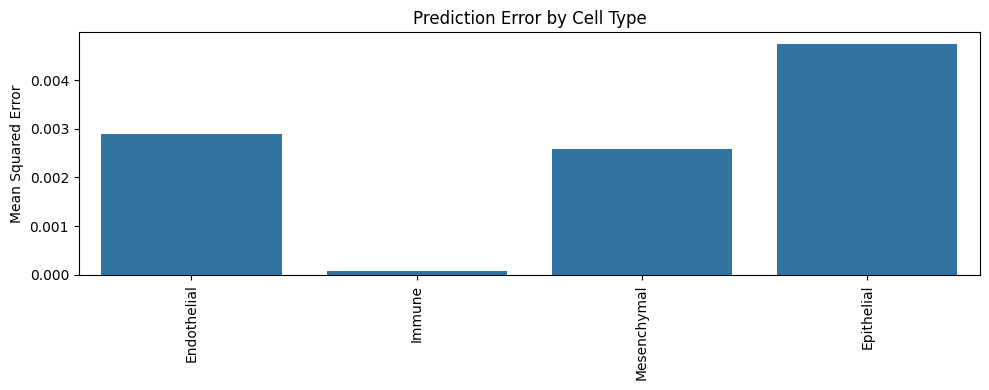

In [70]:
from sklearn.metrics import mean_squared_error

# Compute MSE per cell type
mse_per_celltype = {
    col: mean_squared_error(y_test[col], predicted_proportions[col])
    for col in y_test.columns
}

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(x=list(mse_per_celltype.keys()), y=list(mse_per_celltype.values()))
plt.ylabel("Mean Squared Error")
plt.title("Prediction Error by Cell Type")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Validate on test data

In [61]:
# Get true pseudobulk
adata_test_pseudobulk, true_cell_prop = true_pseudo_bulk_by_sample(adata=adata_test, sample_key="id", cell_type_key="heca_lineage")

convert counts data to array
conversion to array done!
convert to dataframe
add sample name column
add cell type key
group by sample and sum counts
grpup by sample and cell to get cell proportion info
divide by total cell count to get proportion
done!


In [62]:
adata_test_pseudobulk.head(3)

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000236601,...,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000278782,ENSG00000277761,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
id,,,,,,,,,,,,,,,,,,,,,
B2-CZI14N,0.0,0.0,0.0,17.0,1.0,0.0,18.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,17.0,6.0
B3-CZI09N,0.0,0.0,0.0,2.0,0.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
B5-CZI34N,0.0,0.0,0.0,19.0,0.0,0.0,43.0,6.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,5.0,36.0


In [63]:
# convert bulk to anndata
# Create AnnData object
adata_bulk_test = anndata.AnnData(adata_test_pseudobulk)

# Set sample names and gene names
adata_bulk_test.obs_names = adata_test_pseudobulk.index     
adata_bulk_test.var_names = adata_test_pseudobulk.columns 

# Add batch information
adata_bulk_test.obs["batch"] = "czi pseudobulk test"
adata_bulk_test.obs["id"] = adata_test_pseudobulk.index 

In [64]:
# Define scVI path
scvi_path = "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01"

# Extract scVI embeddings with single forward pass
scvi.model.SCVI.prepare_query_anndata(adata_bulk_test, 
                                      scvi_path)

vae_q = scvi.model.SCVI.load_query_data(
    adata_bulk_test,
    scvi_path,
)

# # This allows for a simple forward pass
vae_q.is_trained = True
latent_czi_pseudobulk_test = vae_q.get_latent_representation()

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 63.5375% reference vars in query data.                                                              
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [65]:
latent_czi_pseudobulk_test = pd.DataFrame(latent_czi_pseudobulk_test)

In [66]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(latent_czi_pseudobulk_test)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns.tolist(), index=true_cell_prop.index.tolist())

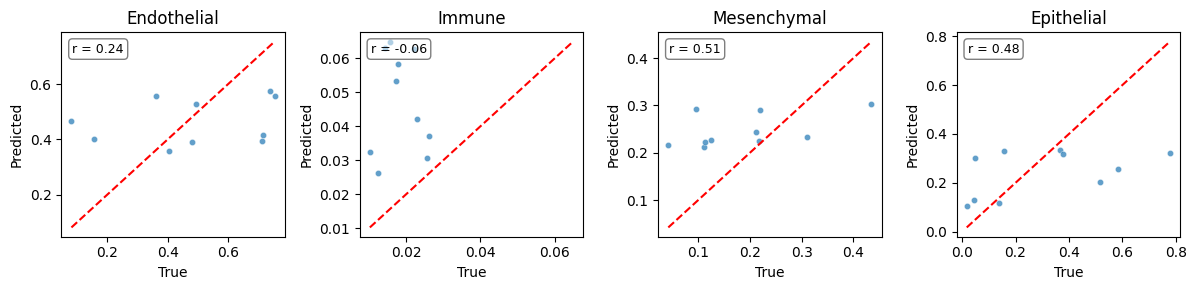

In [67]:
# Plot correlations (pearson)
plot_true_vs_predicted(true_cell_prop,predicted_proportions_test, dot_size=20)

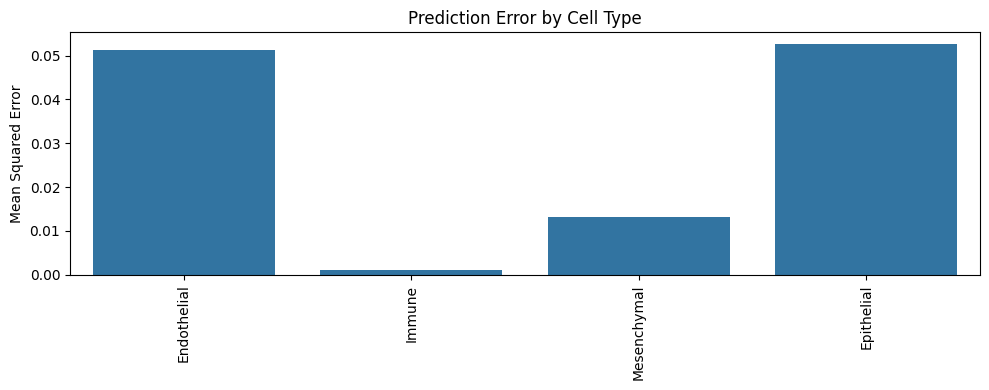

In [76]:
from sklearn.metrics import mean_squared_error

# Compute MSE per cell type
mse_per_celltype = {
    col: mean_squared_error(true_cell_prop[col], predicted_proportions_test[col])
    for col in y_test.columns
}

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(x=list(mse_per_celltype.keys()), y=list(mse_per_celltype.values()))
plt.ylabel("Mean Squared Error")
plt.title("Prediction Error by Cell Type")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Test on all 62 pseudobulked by sample name and see how performance is 

In [ ]:
# Get true pseudobulk
adata_test_pseudobulk_all, true_cell_prop_all = true_pseudo_bulk_by_sample(adata=adata, sample_key="id", cell_type_key="heca_lineage")

convert counts data to array


In [ ]:
# convert bulk to anndata
# Create AnnData object
adata_bulk_test_all = anndata.AnnData(adata_test_pseudobulk_all)

# Set sample names and gene names
adata_bulk_test_all.obs_names = adata_test_pseudobulk_all.index     
adata_bulk_test_all.var_names = adata_test_pseudobulk_all.columns 

# Add batch information
adata_bulk_test_all.obs["batch"] = "czi pseudobulk test"
adata_bulk_test_all.obs["id"] = adata_test_pseudobulk_all.index 

In [ ]:
# Define scVI path
scvi_path = "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01"

# Extract scVI embeddings with single forward pass
scvi.model.SCVI.prepare_query_anndata(adata_bulk_test_all, 
                                      scvi_path)

vae_q = scvi.model.SCVI.load_query_data(
    adata_bulk_test_all,
    scvi_path,
)

# # This allows for a simple forward pass
vae_q.is_trained = True
latent_czi_pseudobulk_test_all = vae_q.get_latent_representation()

latent_czi_pseudobulk_test_all = pd.DataFrame(latent_czi_pseudobulk_test_all)

In [ ]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(latent_czi_pseudobulk_test_all)

# Convert to DataFrame
predicted_proportions_test_all = pd.DataFrame(y_pred, columns=y_train.columns, index=adata_test_pseudobulk_all.index)

In [ ]:
# Plot correlations (pearson)
plot_true_vs_predicted(true_cell_prop_all,predicted_proportions_test_all, dot_size=10)

In [ ]:
from sklearn.metrics import mean_squared_error

# Compute MSE per cell type
mse_per_celltype = {
    col: mean_squared_error(true_cell_prop_all[col], predicted_proportions_test_all[col])
    for col in y_test.columns
}

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(x=list(mse_per_celltype.keys()), y=list(mse_per_celltype.values()))
plt.ylabel("Mean Squared Error")
plt.title("Prediction Error by Cell Type")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Use randomly sampled pseudobulk 

In [71]:
test_czi, test_czi_cell_prop = create_pseudobulk_and_proportions(adata= adata_test, cell_type_col="heca_lineage", sample_id_col="id")

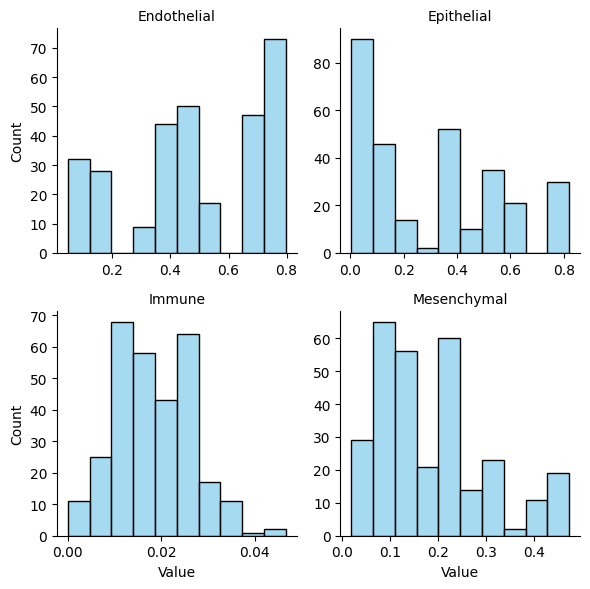

In [72]:
# Explore cell type proportions
# Reshape the data to long format
df_long = test_czi_cell_prop.melt(var_name='Variable', value_name='Value')

# Create facet plot
g = sns.FacetGrid(df_long, col='Variable', col_wrap=2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='Value', bins=10, color='skyblue')

# Adjust layout
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
plt.tight_layout()
plt.show()

In [73]:
# convert bulk to anndata
# Create AnnData object
adata_bulk_test = anndata.AnnData(test_czi)

# Set sample names and gene names
adata_bulk_test.obs_names = test_czi.index     
adata_bulk_test.var_names = test_czi.columns 

# Add batch information
adata_bulk_test.obs["batch"] = "czi pseudobulk"
adata_bulk_test.obs["id"] = test_czi.index 

In [74]:
# Define scVI path
scvi_path = "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01"

# Extract scVI embeddings with single forward pass
scvi.model.SCVI.prepare_query_anndata(adata_bulk_test, 
                                      scvi_path)

vae_q = scvi.model.SCVI.load_query_data(
    adata_bulk_test,
    scvi_path,
)

# # This allows for a simple forward pass
vae_q.is_trained = True
latent_czi_pseudobulk_test = vae_q.get_latent_representation()

latent_czi_pseudobulk_test = pd.DataFrame(latent_czi_pseudobulk_test)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 63.5375% reference vars in query data.                                                              
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [75]:
# Assuming you have a DataFrame `X_bulk_latent` with same features as `X_train`
y_pred = model.predict(latent_czi_pseudobulk_test)

# Convert to DataFrame
predicted_proportions_test = pd.DataFrame(y_pred, columns=y_train.columns, index=test_czi.index)

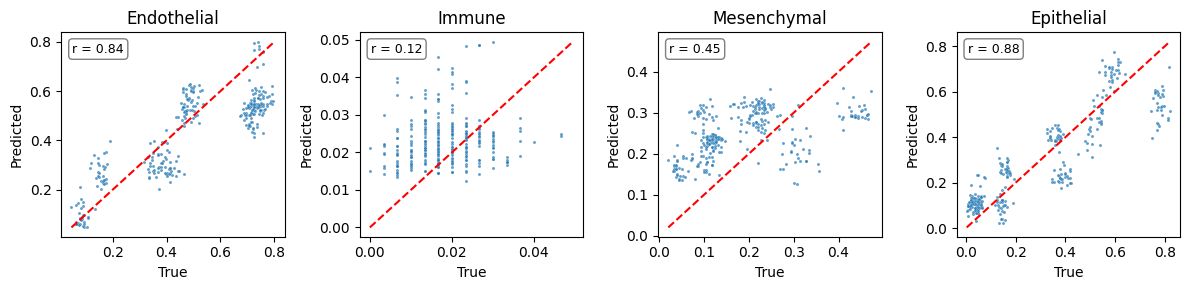

In [76]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop,predicted_proportions_test)

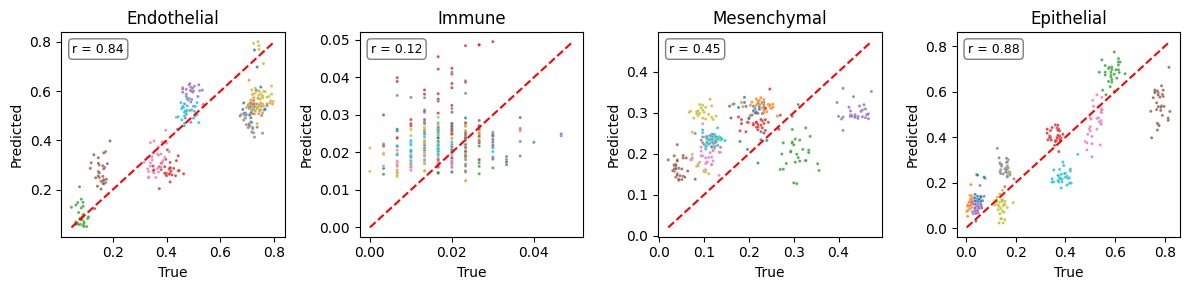

In [77]:
def plot_true_vs_predicted_with_color(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5):

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import pearsonr

    # Sample group for coloring
    color = y_test_df.index.str.split('_').str[0]

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot with hue
        sns.scatterplot(x=x, y=y, hue=color, palette="tab10", alpha=0.8, ax=ax, s=dot_size, legend=False)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
plot_true_vs_predicted_with_color(test_czi_cell_prop,predicted_proportions_test)

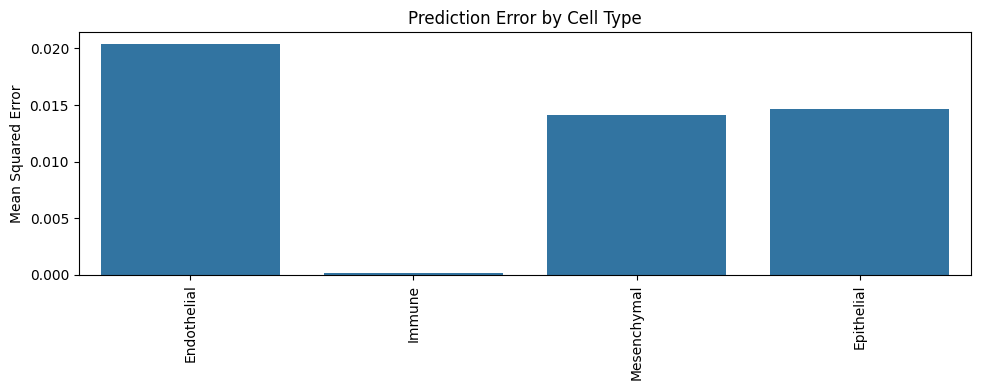

In [78]:
from sklearn.metrics import mean_squared_error

# Compute MSE per cell type
mse_per_celltype = {
    col: mean_squared_error(test_czi_cell_prop[col], predicted_proportions_test[col])
    for col in y_test.columns
}

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(x=list(mse_per_celltype.keys()), y=list(mse_per_celltype.values()))
plt.ylabel("Mean Squared Error")
plt.title("Prediction Error by Cell Type")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()